# Import Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install sqlalchemy psycopg2-binary
from sqlalchemy import create_engine

# Load Data dari GitHUb

In [3]:
# Membaca dataset olist customer dari GitHub
datasets = {
   'customers':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_customers_dataset.csv',
   'order_items':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_order_items_dataset.csv',
   'order_payments':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_order_payments_dataset.csv',
   'order_reviews':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_order_reviews_dataset.csv',
   'orders':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_orders_dataset.csv',
   'products':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_products_dataset.csv',
   'sellers':'https://raw.githubusercontent.com/hastisf/python-data-analyst/refs/heads/master/olist_sellers_dataset.csv'
}


In [4]:
data_tables = {}

for table_name, url in datasets.items():
    if table_name in ['order_items', 'order_payments']:
        data_tables[table_name] = pd.read_csv(
            url,
            encoding='latin1',
            nrows=100000
        )
    else:
        data_tables[table_name] = pd.read_csv(
            url,
            encoding='latin1'
        )

In [5]:
df_cust = data_tables['customers']
df_order= data_tables['order_items']
df_payments= data_tables['order_payments']
df_reviews= data_tables['order_reviews']
df_orderdataset= data_tables['orders']
df_products = data_tables['products']
df_sellers= data_tables['sellers']

# Informasi Dataset

## Info

In [6]:
df_cust.info()
df_order.info()
df_payments.info()
df_reviews.info()
df_orderdataset.info()
df_products.info()
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             100000 non-null  object 
 1   order_item_id        100000 non-null  int64  
 2   product_id           100000 non-null  object 
 3   seller_id            100000 non-null  object 
 4   shipping_limit_date  100000 non-null  object

## Describe

In [7]:
df_cust.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [8]:
df_order.describe()

,order_item_id,price,freight_value
count,100000.000000,100000.000000,100000.000000
mean,1.199040,120.912239,20.000391
std,0.714205,183.119046,15.853848
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.270000
75%,1.000000,134.990000,21.170000
max,21.000000,6735.000000,409.680000


In [9]:
df_payments.describe()

,payment_sequential,payment_installments,payment_value
count,100000.000000,100000.000000,100000.000000
mean,1.092780,2.855080,154.302131
std,0.709744,2.687629,217.737383
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.860000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,172.160000
max,29.000000,24.000000,13664.080000


In [10]:
df_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [11]:
df_orderdataset.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [12]:
df_products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [13]:
df_sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


## Missing Value

In [14]:
df_cust.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [15]:
df_order.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [16]:
df_payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [17]:
df_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [18]:
df_orderdataset.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [19]:
df_products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [20]:
df_sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


# Cek Duplikat

In [21]:
df_cust.duplicated().sum()

np.int64(0)

In [22]:
df_cust.duplicated().sum()

np.int64(0)

In [23]:
df_order.duplicated().sum()

np.int64(0)

In [24]:
df_payments.duplicated().sum()

np.int64(0)

In [25]:
df_reviews.duplicated().sum()

np.int64(0)

In [26]:
df_orderdataset.duplicated().sum()

np.int64(0)

In [27]:
df_products.duplicated().sum()

np.int64(0)

In [28]:
df_sellers.duplicated().sum()

np.int64(0)

# Handle Missing Value

In [29]:
df_reviews=df_reviews.drop(columns=['review_comment_title','review_comment_message'])

In [30]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [31]:
df_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [32]:
df_products=df_products.dropna(subset=["product_category_name"])

# Ubah Tipe Data

In [33]:
# Mnegubah Tipe Data Object ke Datetime
df_orderdataset['order_purchase_timestamp'] = pd.to_datetime(df_orderdataset['order_purchase_timestamp'])
df_orderdataset['order_approved_at'] = pd.to_datetime(df_orderdataset['order_approved_at'])
df_orderdataset['order_delivered_carrier_date'] = pd.to_datetime(df_orderdataset['order_delivered_carrier_date'])
df_orderdataset['order_delivered_customer_date'] = pd.to_datetime(df_orderdataset['order_delivered_customer_date'])
df_orderdataset['order_estimated_delivery_date'] = pd.to_datetime(df_orderdataset['order_estimated_delivery_date'])
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'])
df_products['produxt_photos_qty'] = df_products['product_photos_qty'].astype('Int64')
df_products['product_weight_g'] = df_products['product_weight_g'].astype('Int64')
df_products['product_length_cm'] = df_products['product_length_cm'].astype('Int64')
df_products['product_height_cm'] = df_products['product_height_cm'].astype('Int64')
df_products['product_width_cm'] = df_products['product_width_cm'].astype('Int64')

/tmp/ipykernel_1407/2753852267.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_products['produxt_photos_qty'] = df_products['product_photos_qty'].astype('Int64')
/tmp/ipykernel_1407/2753852267.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_products['product_weight_g'] = df_products['product_weight_g'].astype('Int64')
/tmp/ipykernel_1407/2753852267.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

# Koneksi ke DBeaver

In [34]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql",
    username="postgres.krlxrocqmvzelxascvje",
    password="Hastinafis150226",
    host="aws-1-ap-southeast-1.pooler.supabase.com",
    port=6543,
    database="postgres",
    query={"sslmode": "require"})

engine = create_engine(url)

In [35]:
push_tables = {
    'customers': df_cust,
    'order_items': df_order,
    'order_payments': df_payments,
    'order_reviews': df_reviews,
    'orders': df_orderdataset,
    'products': df_products,
    'sellers': df_sellers
}

for table_name, df in push_tables.items():

    print(f'Mengirim tabel {table_name} ke database...')

    df.to_sql(
        table_name,
        engine,
        if_exists='replace',
        index=False
    )

Mengirim tabel customers ke database...
Mengirim tabel order_items ke database...
Mengirim tabel order_payments ke database...
Mengirim tabel order_reviews ke database...
Mengirim tabel orders ke database...
Mengirim tabel products ke database...
Mengirim tabel sellers ke database...


# Visualisasi dengan Matplotlib

## 1. Top Product Category Berdasarkan Revenue (Barchart)


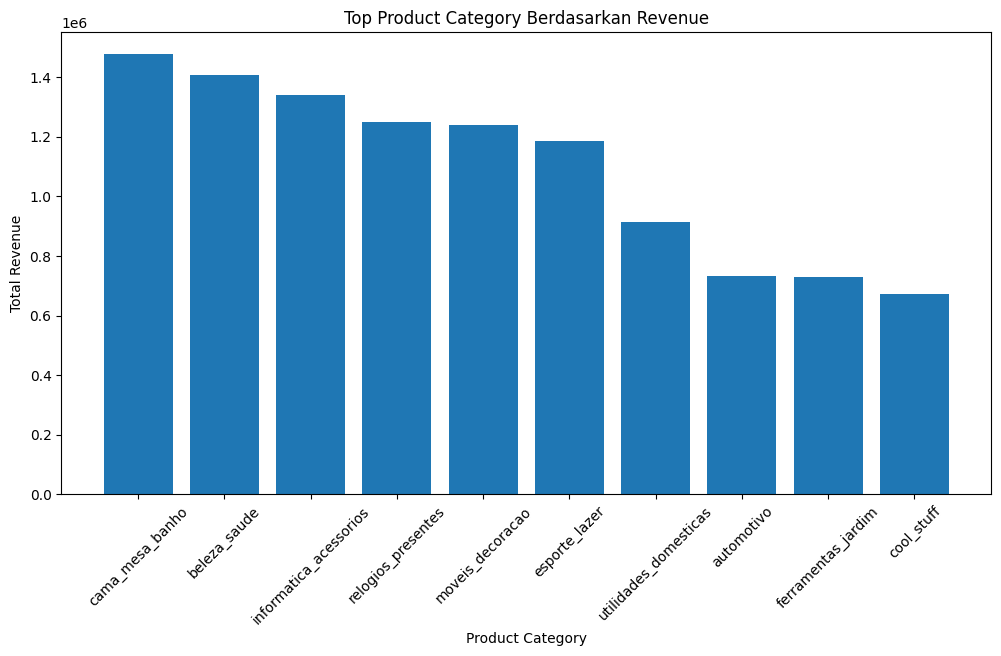

In [36]:
query_1 = pd.merge(df_orderdataset, df_order, on='order_id')
query_1 = pd.merge(query_1, df_products, on='product_id')
query_1 = pd.merge(query_1, df_payments, on='order_id')

query_1 = query_1.groupby(
    'product_category_name')['payment_value'].sum().reset_index()

query_1 = query_1.sort_values(
    by='payment_value',
    ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    query_1['product_category_name'],
    query_1['payment_value'])

plt.title('Top Product Category Berdasarkan Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 2. Kota Customer dengan Jumlah Order Terbanyak (Horizontal Barchart)



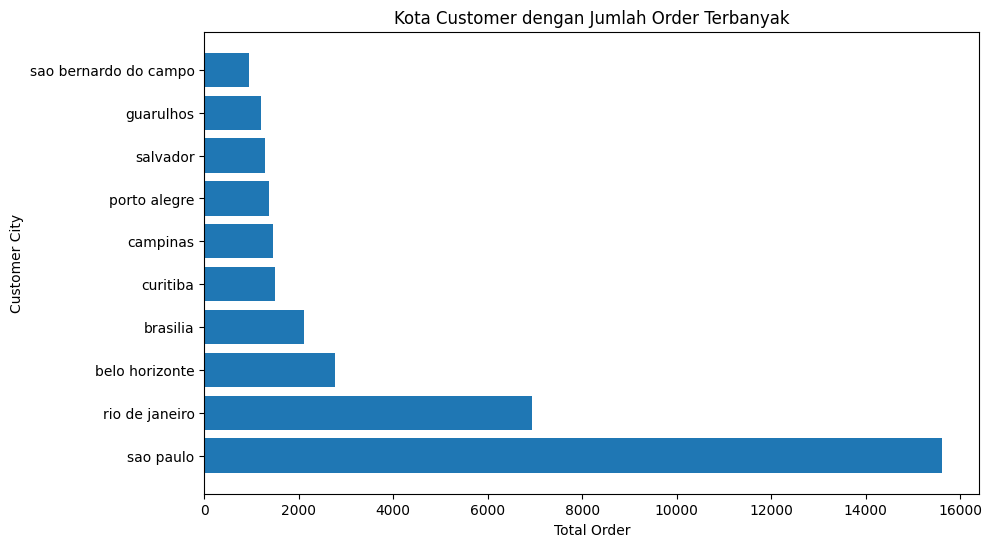

In [37]:
query_2 = pd.merge(df_orderdataset, df_cust, on='customer_id')
query_2 = pd.merge(query_2, df_payments, on='order_id')

query_2 = query_2.groupby(
    'customer_city')['order_id'].count().reset_index()

query_2 = query_2.sort_values(
    by='order_id',
    ascending=False).head(10)

query_2.columns = ['customer_city', 'total_order']

plt.figure(figsize=(10,6))

plt.barh(
    query_2['customer_city'],
    query_2['total_order']
)

plt.title('Kota Customer dengan Jumlah Order Terbanyak')
plt.xlabel('Total Order')
plt.ylabel('Customer City')
plt.show()

## 3.Metode Pembayaran Paling Banyak Digunakan (Piechart)


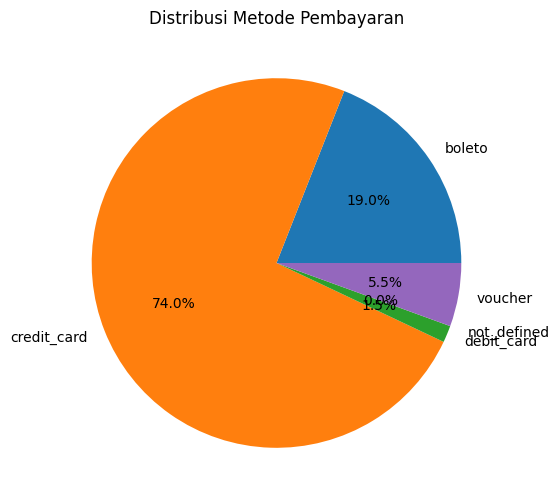

In [38]:
query_3 = pd.merge(df_orderdataset, df_payments, on='order_id')
query_3 = pd.merge(query_3, df_cust, on='customer_id')

query_3 = query_3.groupby(
    'payment_type')['order_id'].count().reset_index()

query_3.columns = ['payment_type', 'total_transaction']

plt.figure(figsize=(8,6))

plt.pie(
    query_3['total_transaction'],
    labels=query_3['payment_type'],
    autopct='%1.1f%%')

plt.title('Distribusi Metode Pembayaran')
plt.show()

## 4. Total Order Berdasarkan Bulan (Linechart)

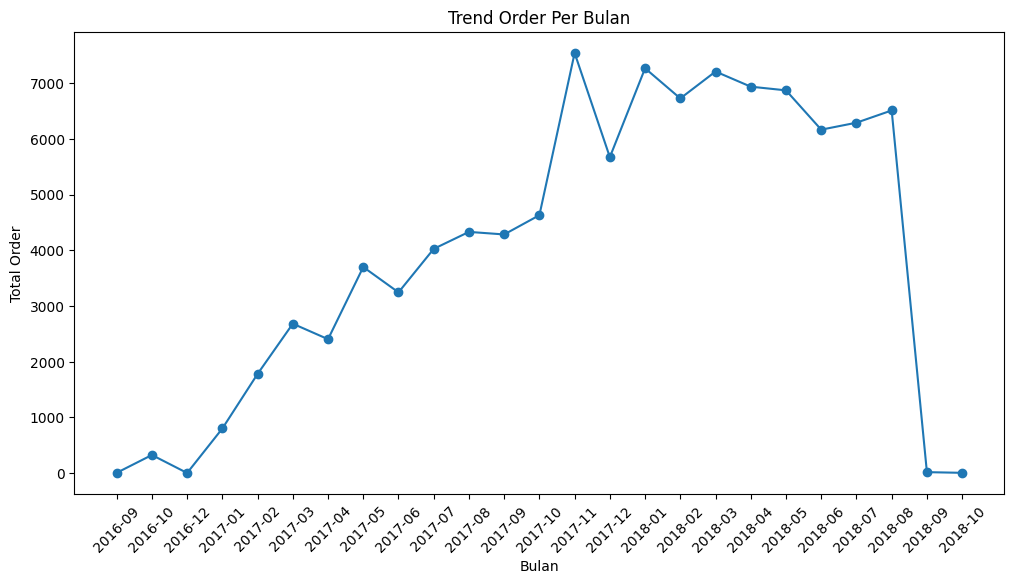

In [39]:
# memastikan kolom tanggal bertipe datetime
df_orderdataset['order_purchase_timestamp'] = pd.to_datetime(
    df_orderdataset['order_purchase_timestamp'])

# membuat data order bulanan
query_order_bulanan = df_orderdataset.groupby(
    df_orderdataset['order_purchase_timestamp'].dt.to_period('M')
)['order_id'].count().reset_index()

# rename kolom
query_order_bulanan.columns = ['bulan', 'total_order']

# ubah period menjadi string agar mudah divisualisasikan
query_order_bulanan['bulan'] = query_order_bulanan['bulan'].astype(str)

# line chart
plt.figure(figsize=(12,6))

plt.plot(
    query_order_bulanan['bulan'],
    query_order_bulanan['total_order'],
    marker='o')

plt.title('Trend Order Per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Order')
plt.xticks(rotation=45)
plt.show()

# Visualisasi dengan Seaborn

## 5.Seller dengan Revenue Tertinggi (BarChart)

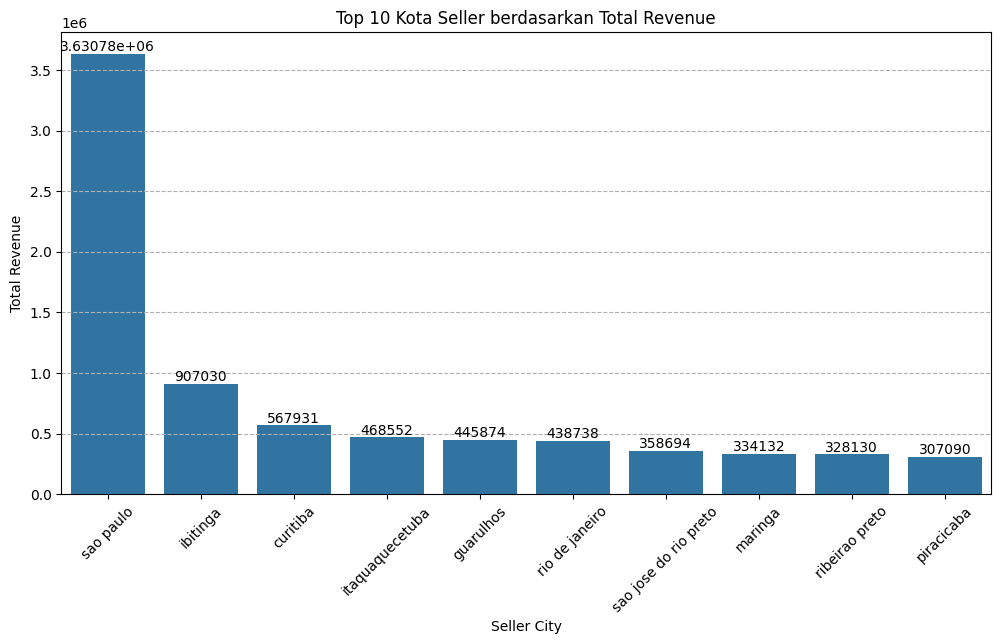

In [40]:
query_5 = pd.merge(df_order, df_sellers, on='seller_id')
query_5 = pd.merge(
    query_5,
    df_payments,
    on='order_id')

query_5 = query_5.groupby('seller_city'
)['payment_value'].sum().reset_index()

query_5 = query_5.sort_values(
    by='payment_value',
    ascending=False).head(10)

query_5.columns = [
    'seller_city',
    'total_revenue']

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=query_5,
    x='seller_city',
    y='total_revenue')

for i in ax.containers:
    ax.bar_label(i,)

plt.grid(axis="y",linestyle="--")

plt.title('Top 10 Kota Seller berdasarkan Total Revenue')
plt.xlabel('Seller City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 6. Kategori Produk yang Paling Banyak Terjual (Bar Chart)


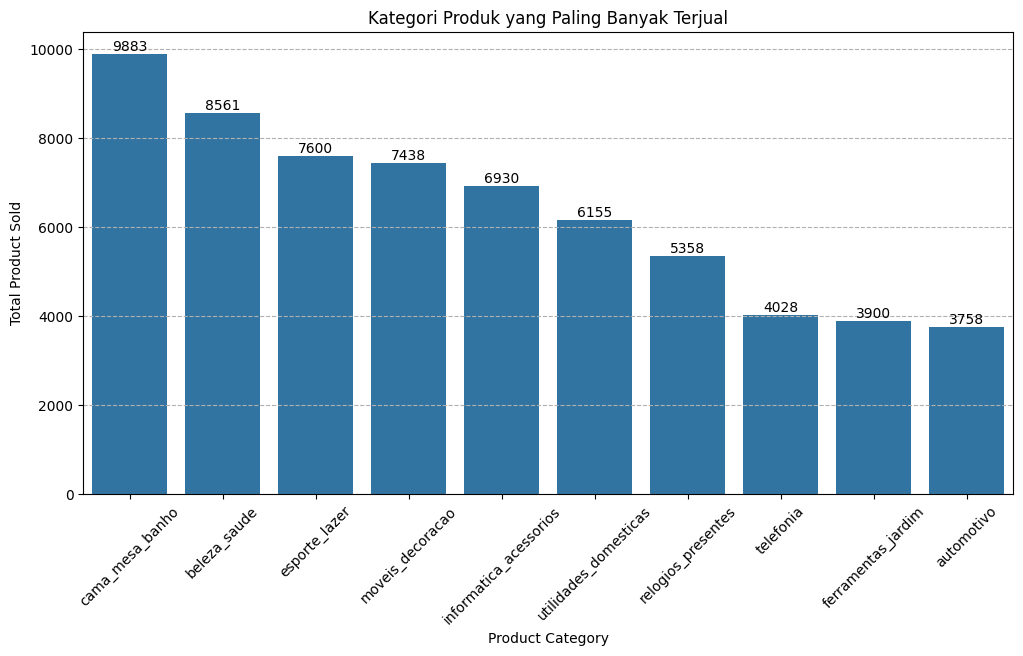

In [41]:
query_6 = pd.merge(df_order, df_products, on='product_id')

query_6 = query_6.groupby(
    'product_category_name'
)['product_id'].count().reset_index()

query_6 = query_6.sort_values(
    by='product_id',
    ascending=False).head(10)

query_6.columns = [
    'product_category_name',
    'total_product_sold']

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=query_6,
    x='product_category_name',
    y='total_product_sold')

for i in ax.containers:
    ax.bar_label(i,)

plt.grid(axis="y",linestyle="--")
plt.title('Kategori Produk yang Paling Banyak Terjual')
plt.xlabel('Product Category')
plt.ylabel('Total Product Sold')
plt.xticks(rotation=45)
plt.show()

## 7. Revenue Berdasarkan State Customer (Bar Chart)


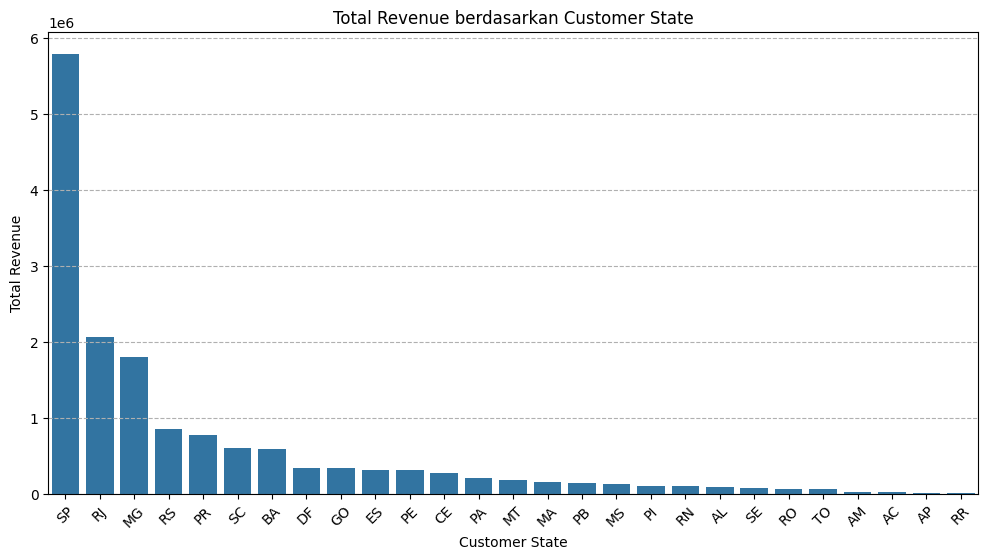

In [42]:
query_7 = pd.merge(df_orderdataset, df_cust, on='customer_id')

query_7 = pd.merge(
    query_7,
    df_payments,
    on='order_id')

query_7 = query_7.groupby(
    'customer_state'
)['payment_value'].sum().reset_index()

query_7 = query_7.sort_values(
    by='payment_value',
    ascending=False)

query_7.columns = [
    'customer_state',
    'total_revenue']

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=query_7,
    x='customer_state',
    y='total_revenue')

plt.grid(axis="y", linestyle="--")
plt.title('Total Revenue berdasarkan Customer State')
plt.xlabel('Customer State')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

## 8. Status Pengiriman Berdasarkan Rata-Rata Review


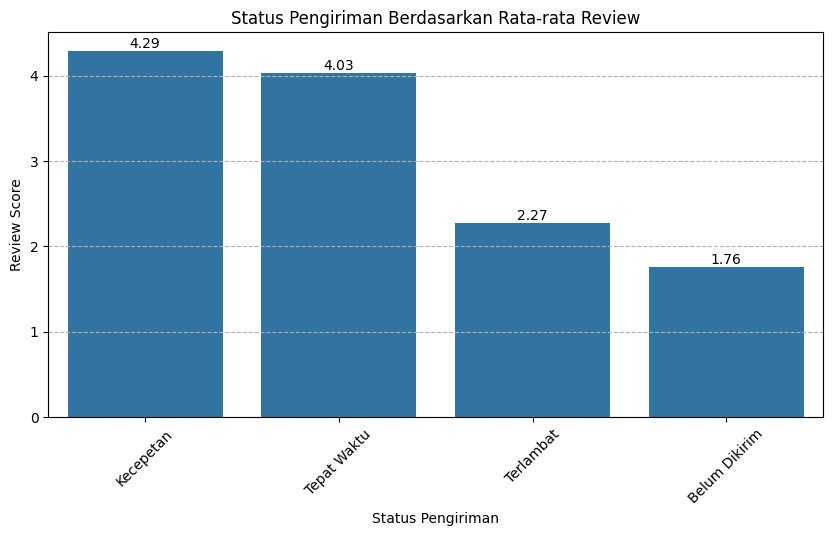

In [43]:
# 1. Clean Datetime -> Date Only
df_orderdataset['order_delivered_customer_date'] = pd.to_datetime(
    df_orderdataset['order_delivered_customer_date']).dt.normalize()

df_orderdataset['order_estimated_delivery_date'] = pd.to_datetime(
    df_orderdataset['order_estimated_delivery_date']).dt.normalize()


# 2. Klasifikasi Status Pengiriman
df_orderdataset['status_pengiriman'] = np.where(
    df_orderdataset['order_delivered_customer_date'].isna(),
    'Belum Dikirim',
    np.where(
        df_orderdataset['order_delivered_customer_date'] < df_orderdataset['order_estimated_delivery_date'],
        'Kecepetan',
        np.where(
            df_orderdataset['order_delivered_customer_date'] == df_orderdataset['order_estimated_delivery_date'],
            'Tepat Waktu',
            'Terlambat')))

# 3. Merge dengan Review
query_8 = pd.merge(
    df_orderdataset,
    df_reviews,
    on='order_id',
    how='left')

# 4. Aggregation
query_8 = query_8.groupby('status_pengiriman').agg(
    average_review=('review_score', 'mean'),
    total_order=('order_id', 'count')).reset_index()

# 5. Sorting
query_8 = query_8.sort_values(by='average_review', ascending=False)

# 6. Visualization
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=query_8,
    x='status_pengiriman',
    y='average_review')

ax.bar_label(ax.containers[0], fmt='%.2f')

plt.grid(axis="y",linestyle="--")
plt.title('Status Pengiriman Berdasarkan Rata-rata Review')
plt.xlabel('Status Pengiriman')
plt.ylabel('Review Score')
plt.xticks(rotation=45)
plt.show()